# Paper 參數抽樣、Annual 45 與 Monthly 540 的空間驗證

依 Rai et al. (2024) 第 2.4 節，NN 訓練資料先直接抽參數組合：$\mu\sim U(1,50)$、$\sigma\sim U(0.1,40)$、$\xi\sim U(-0.4,1)$，再依每組參數模擬 GEV 樣本、做 median/IQR 標準化並取 11 個分位數。


In [1]:
from pathlib import Path
import runpy

cwd = Path.cwd().resolve()
if (cwd / "src" / "project_paths.py").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "src" / "project_paths.py").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError("請從 repository 根目錄或 notebooks/ 執行。")

NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"
SCRIPT_PATH = PROJECT_ROOT / "src" / "annual_monthly_max_comparison.py"
_ = runpy.run_path(str(SCRIPT_PATH), run_name="__main__")


      scenario parameter  n_obs_per_grid     rmse  nrmse_by_spatial_sd      mae      bias  correlation
     annual_45        mu              45 0.195966             0.097997 0.161457  0.020570     0.995326
     annual_45     sigma              45 0.198868             1.384341 0.157361 -0.087136     0.631839
     annual_45        xi              45 0.115339             3.638665 0.094549  0.020432     0.242032
   monthly_540        mu             540 0.058936             0.029472 0.048637  0.001725     0.999570
   monthly_540     sigma             540 0.063975             0.445336 0.049622 -0.005460     0.912911
   monthly_540        xi             540 0.037869             1.194674 0.030243  0.002663     0.554074
  annual_45_gp        mu              45 0.108258             0.054137 0.089507  0.020635     0.998594
  annual_45_gp     sigma              45 0.175483             1.221556 0.140047 -0.086976     0.680851
  annual_45_gp        xi              45 0.109248             3.446499 0.

模型與 paper 設定核對


,weight_path,weight_bytes,weight_sha256,network,trainable_parameters,retrained,paper_training_parameter_sampling,spatial_truth_note
0,C:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast ...,2461079,d936d3f923a4275a81cd2d0b3046b25b1ee350392f66f3...,11-512-512-512-128-128-3,614019,False,"mu~Uniform(1,50); sigma~Uniform(0.1,40); xi~Un...",smooth benchmark surfaces inside the paper par...


Raw NN 與 GP 平滑後的誤差


,scenario,parameter,n_obs_per_grid,rmse,nrmse_by_spatial_sd,mae,bias,correlation
0,annual_45,mu,45,0.195966,0.097997,0.161457,0.020570,0.995326
1,annual_45,sigma,45,0.198868,1.384341,0.157361,-0.087136,0.631839
2,annual_45,xi,45,0.115339,3.638665,0.094549,0.020432,0.242032
3,monthly_540,mu,540,0.058936,0.029472,0.048637,0.001725,0.999570
4,monthly_540,sigma,540,0.063975,0.445336,0.049622,-0.005460,0.912911
5,monthly_540,xi,540,0.037869,1.194674,0.030243,0.002663,0.554074
6,annual_45_gp,mu,45,0.108258,0.054137,0.089507,0.020635,0.998594
7,annual_45_gp,sigma,45,0.175483,1.221556,0.140047,-0.086976,0.680851
8,annual_45_gp,xi,45,0.109248,3.446499,0.089577,0.020432,0.242032
9,monthly_540_gp,mu,540,0.040519,0.020262,0.030979,0.001720,0.999797


各情境、各參數選到的 GP kernel


,scenario,parameter,kernel,initial_length_scale,nu,standardized_rmse,optimized_kernel
0,annual_45,mu,RBF,0.1,NaN,0.054137,1.05**2 * RBF(length_scale=0.896) + WhiteKerne...
35,annual_45,sigma,Matern,0.1,0.5,1.221556,"0.934**2 * Matern(length_scale=0.385, nu=0.5) ..."
82,annual_45,xi,Matern,3.0,2.5,3.446499,"0.972**2 * Matern(length_scale=0.0381, nu=2.5)..."
87,monthly_540,mu,RBF,1.0,NaN,0.020262,1.26**2 * RBF(length_scale=0.969) + WhiteKerne...
117,monthly_540,sigma,RBF,3.0,NaN,0.185417,1.47**2 * RBF(length_scale=2.2) + WhiteKernel(...
166,monthly_540,xi,Matern,3.0,2.5,1.078492,"0.944**2 * Matern(length_scale=0.171, nu=2.5) ..."


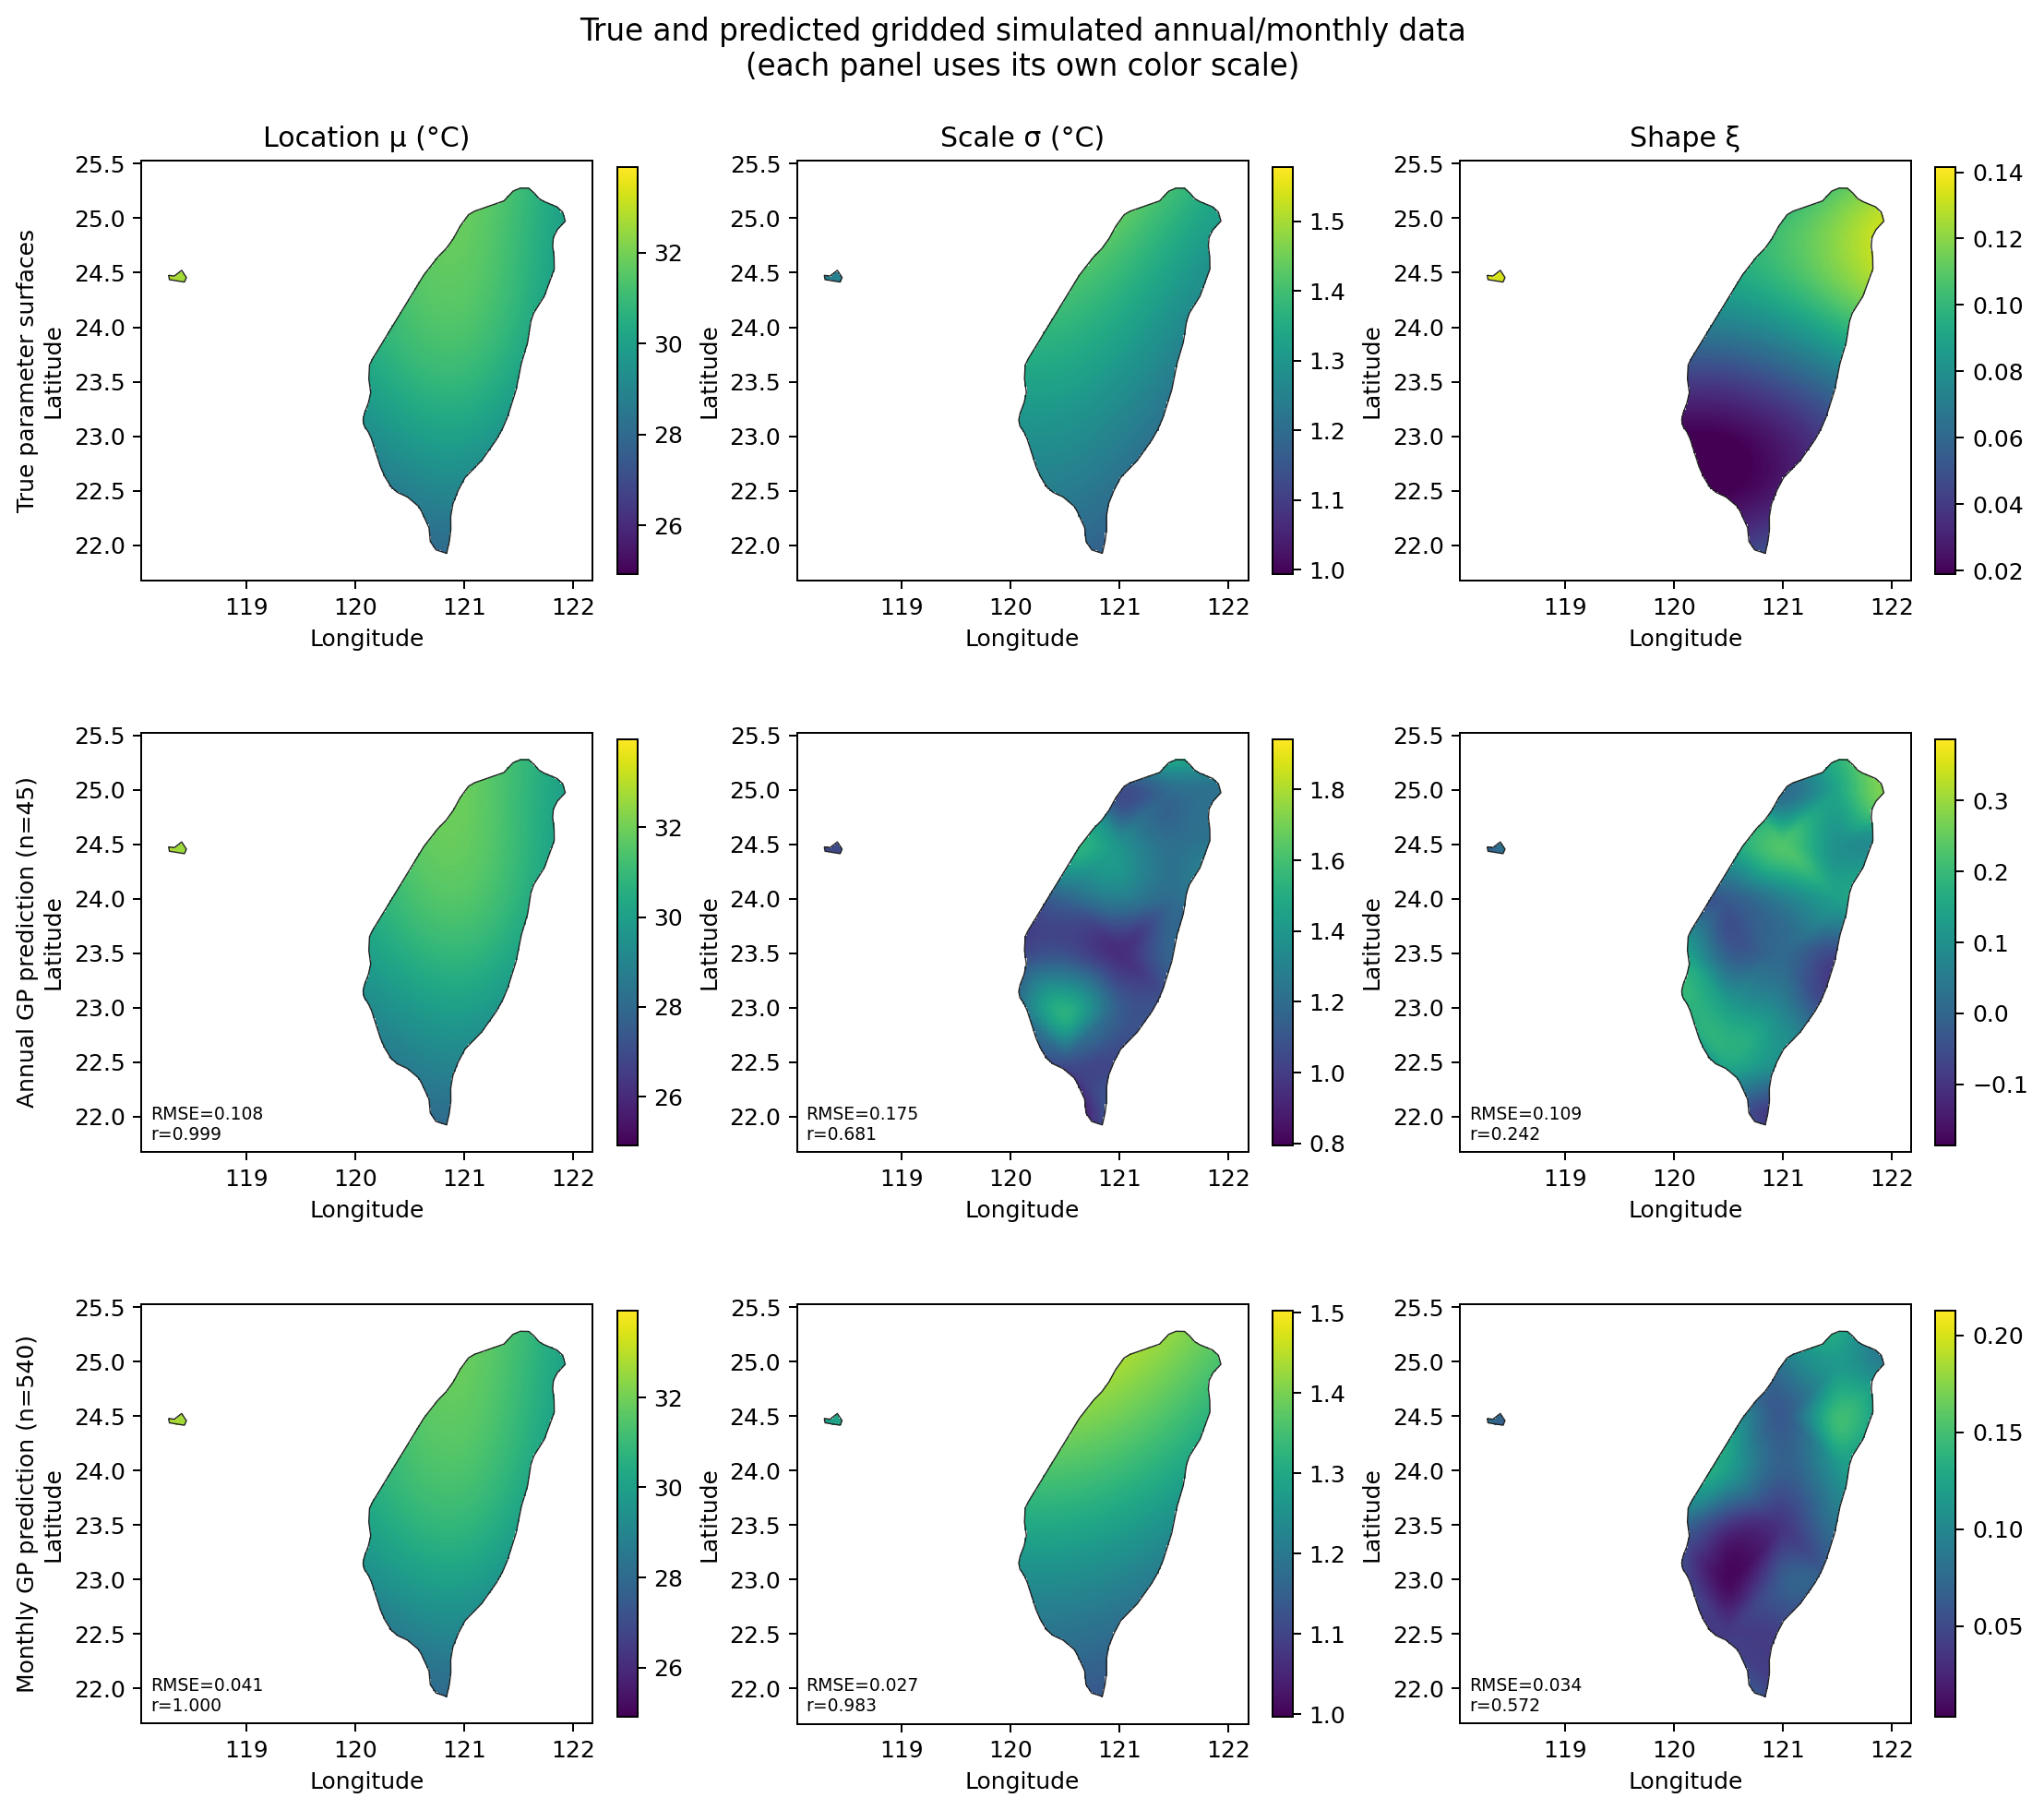

In [2]:
from IPython.display import Image, display
import pandas as pd

FIG_PATH = (
    PROJECT_ROOT
    / "results"
    / "figures"
    / "annual_vs_monthly_block_maxima_comparison.png"
)
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
ERROR_PATH = PROCESSED_DIR / "annual_vs_monthly_block_maxima_error.csv"
AUDIT_PATH = PROCESSED_DIR / "annual_monthly_model_audit.csv"
GP_SEARCH_PATH = PROCESSED_DIR / "annual_monthly_gp_kernel_search.csv"
WEIGHT_PATH = PROJECT_ROOT / "models" / "best_baseline_model.pth"

print("模型與 paper 設定核對")
display(pd.read_csv(AUDIT_PATH))
print("Raw NN 與 GP 平滑後的誤差")
display(pd.read_csv(ERROR_PATH))
print("各情境、各參數選到的 GP kernel")
gp_search = pd.read_csv(GP_SEARCH_PATH)
display(gp_search.loc[gp_search["selected"] == True, [
    "scenario", "parameter", "kernel", "initial_length_scale",
    "nu", "standardized_rmse", "optimized_kernel"
]])
display(Image(filename=str(FIG_PATH)))


## 真實資料的規則（與上面的模擬敏感度實驗分開）

真實 TCCIP 資料必須從**每日最高溫**開始處理：

1. 每個 GRID、每個月，取該月所有日最高溫的最大值。
2. 月份日資料涵蓋率未達 90% 的值不送入模型。
3. 每個 GRID 的月最大值序列經 robust standardization 後取 11 個經驗分位數。
4. 將這 11 個分位數送入既有 `best_baseline_model.pth` 推論 $\hat\mu,\hat\sigma,\hat\xi$。


In [3]:
import sys
import numpy as np
import torch

DAILY_RAW_DIR = PROJECT_ROOT / "data" / "original_data" / "觀測_日資料_臺灣_最高溫"
OUTPUT_DIR = PROJECT_ROOT / "data" / "processed"
PROJECT_SRC = PROJECT_ROOT / "src"
for source_dir in (PROJECT_SRC,):
    if str(source_dir) not in sys.path:
        sys.path.insert(0, str(source_dir))

daily_files = sorted(DAILY_RAW_DIR.glob("*.csv")) if DAILY_RAW_DIR.exists() else []
if daily_files:
    from prepare_daily_tmax_block_maxima import prepare_daily_tmax_block_maxima
    from gev_nn import GEVNet, estimate_one

    prepared = prepare_daily_tmax_block_maxima(
        raw_dir=DAILY_RAW_DIR,
        output_dir=OUTPUT_DIR,
        start_year=1980,
        min_daily_coverage=0.90,
    )
    monthly = pd.read_csv(prepared["monthly"], index_col=[0, 1])
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = GEVNet().to(device)
    try:
        state = torch.load(WEIGHT_PATH, map_location=device, weights_only=True)
    except TypeError:
        state = torch.load(WEIGHT_PATH, map_location=device)
    model.load_state_dict(state)
    model.eval()

    rows = []
    for station in monthly.columns:
        values = monthly[station].dropna().to_numpy(dtype=float)
        if len(values) < 20:
            continue
        mu_hat, sigma_hat, shape_c_hat = estimate_one(model, values, device)
        rows.append({
            "station": station,
            "n_monthly_maxima": len(values),
            "mu_hat": mu_hat,
            "sigma_hat": sigma_hat,
            "log_sigma_hat": np.log(sigma_hat),
            "xi_hat": -shape_c_hat,
        })

    real_monthly_params = pd.DataFrame(rows)
    real_output = OUTPUT_DIR / "real_monthly_block_maxima_nn_params.csv"
    real_monthly_params.to_csv(real_output, index=False, encoding="utf-8-sig")
    display(prepared)
    display(real_monthly_params.head())
    print("Saved:", real_output)
else:
    print("尚未找到 TCCIP 每日最高溫 CSV，因此沒有把現有月平均資料誤送入模型。")
    print("請把日資料放到：", DAILY_RAW_DIR)

尚未找到 TCCIP 每日最高溫 CSV，因此沒有把現有月平均資料誤送入模型。
請把日資料放到： C:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast parameter estimate\fast_parameter_using_NN\data\original_data\觀測_日資料_臺灣_最高溫
